# 3.4 Nonlinear Regression Gauss Newton Method

In [2]:
using Random
using Zygote
using Optimization
using CairoMakie
using Distributions
using OptimizationOptimisers

Suppose you are asked to fit a function of the following form to some data

$f_{model}(\vec{a},x)=a_1(1-e^{a_2x})$

With this problem, you cannot linearise.  The function is nonlinear in terms of $x$ and also in terms of its coefficients $a_1$ and $a_2$.  The least squares method described in notebooks 3.1 and 3.2 would not work (because your model is now nonlinear in terms of coefficients $a_1$ and $a_2$.  How do we fit this function to some data?

Let's generate some fictitious dataset

In [3]:
N_SAMPLES=5 #50 data points
rng=Xoshiro(1) #my random number generator

x_samples=rand(rng,Uniform(0,5),N_SAMPLES) #generate random values of x between -1 and 1
y_noise=rand(rng,Normal(0.0,0.1),N_SAMPLES) #generate some noise, normal distribution with standard deviation of 0.1
y_samples=4*(1.0.-exp.(-1.8*x_samples))+y_noise; #y=2x+3+epsilon

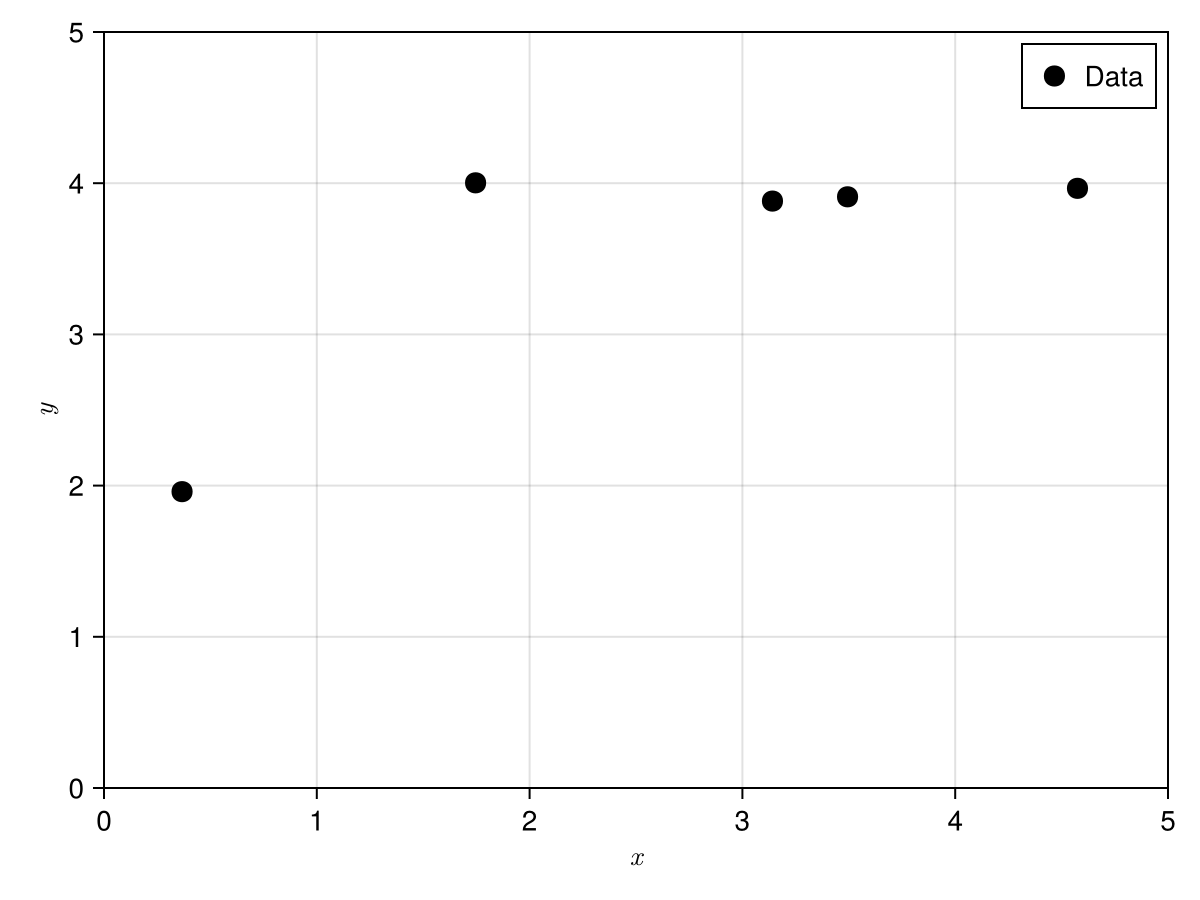

In [4]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(0,5,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black,markersize=15)
axislegend(ax;position = :rt)
fig

We will define a model of the same form as the data.

$f_{model}(\vec{a},x)=a_1(1-e^{a_2x})$

Hence, our task now is to find $a_1$ and $a_2$ such that $f_{model}(\vec{a},x)$ closely approximates $(x_i,y_i)$.  


Since our model is exactly the same form as our data, if our program is right, we should get $a_1=4$ and $a_2=-1.8$. 

In [5]:
fmodel(a,x)=a[1].*(1.0.-exp.(a[2]*x)); # for this model a[1]=a1 and a[2]=a2.

Let's pretend we do not know the values of $a_1$ and $a_2$ and let them both to be equal to 1.0 and -1.0 respectively.  Remember that for real data, you do not know what $a_1$ and $a_2$ are.

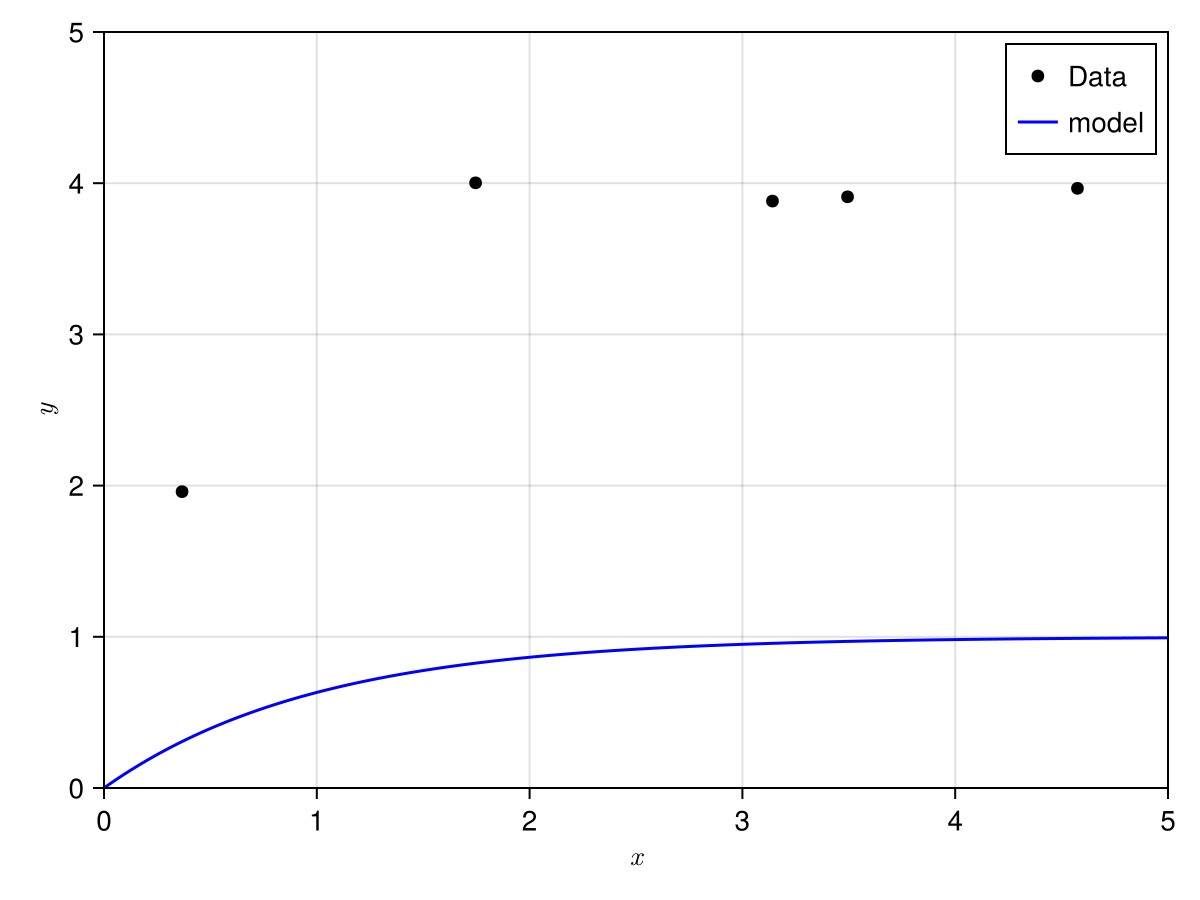

In [6]:
a=[1.0,-1.0] #initial assumptions of the values of  a1, a2 
xplot=Array(0:0.01:5)


fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(0,5,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
lines!(ax,xplot,fmodel(a,xplot);label="model",color=:blue)
axislegend(ax;position = :rt)
fig

Calculating the Jacobian

As can be seen from the graph above, $f_{model}$ is not a good match to the dataset.  We can quantify the error by defining a `custom_loss()` function.  As with the least squares method,  `custom_loss()` is defined as $L(\vec{a})=\frac{1}{2}\sum\limits_{i=1}^{N}(y_i-f_{model}(\vec{a},x_i))^2$. Remember that $\vec{a}$ in this example is a vector consisting of 2 scalar values, i.e. 

$\vec{a}=\begin{Bmatrix}a_1\\
a_2\end{Bmatrix}$.

 For $f_{model}(\vec{a},x) $ to best approximate the true function $y(x)$, we need to choose $a_0$ and $a_1$ such that $L(\vec{a})$ is as small as possible.  We have now cast this as an optimisation problem.

In [7]:
function custom_loss(parameters,x_samples)
           ŷ = fmodel(parameters, x_samples)
           0.5*sum((y_samples .- ŷ).^2)
end

custom_loss (generic function with 1 method)

Let's compute my `custom_loss()` for my current model with $a_1=1$ and $a_2=-1$.

In [8]:
custom_loss(a,x_samples)

19.44195313985992

The number above says that our current error between data and model is 19.4...


For this simple example, we can plot the `custom_loss()` function for different values of $a_0$ and $a_1$ and explore how this `custom_loss()` values changes for different values of $a_0$ and $a_1$.

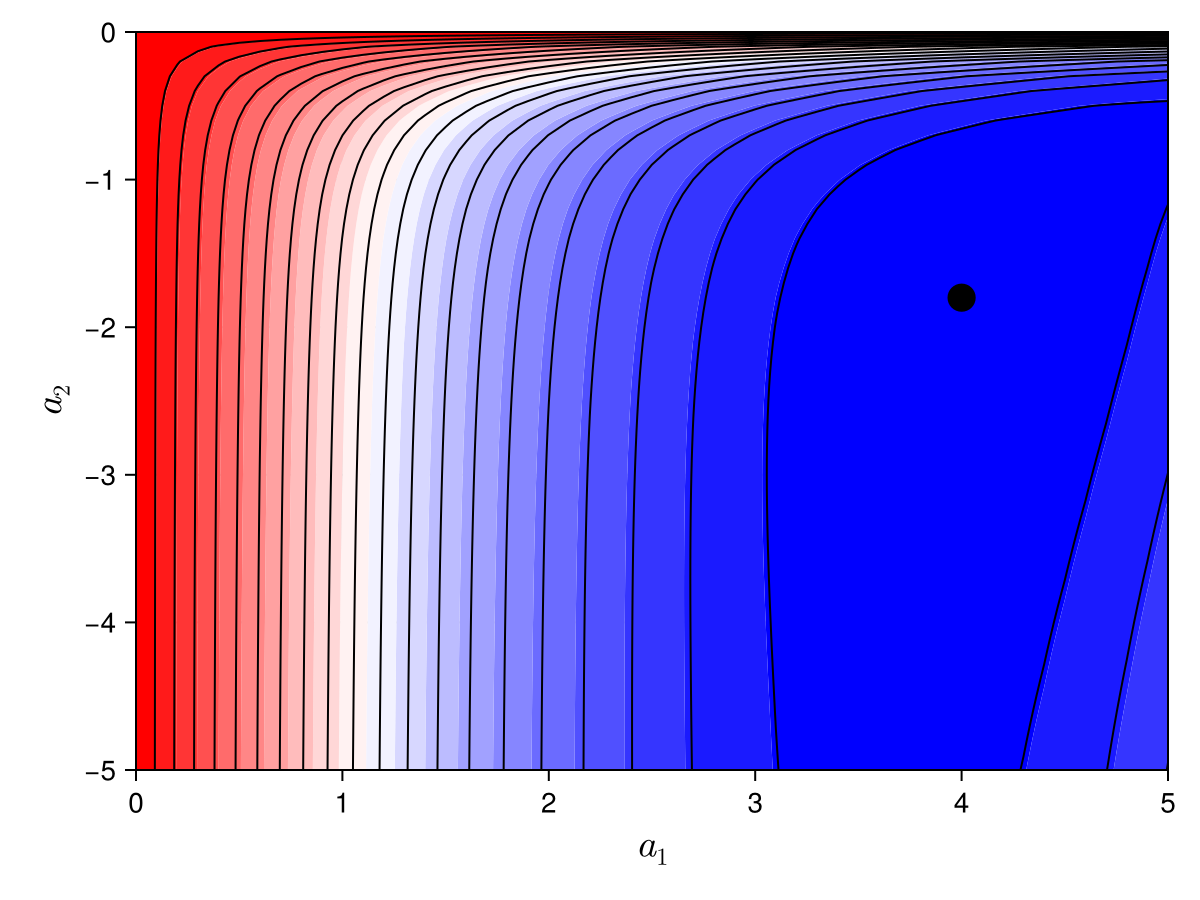

In [9]:
a1range=0:0.1:5
a2range=0:-0.1:-5
loss_values=[custom_loss([a1,a2],x_samples) for a1 in a1range, a2 in a2range]

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"a_1", ylabel = L"a_2",limits=(0,5.0,-5.0,0.0),    
    xlabelsize = 20, # Set X label size
    ylabelsize = 20)  # Set Y label size
contourf!(ax,a1range,a2range,loss_values; levels=20,colormap=:bwr)
contour!(ax,a1range,a2range,loss_values; levels=20,color=:black)
scatter!(ax,[4],[-1.8];markersize=20,color=:black)
fig

For the plot above, I have marked the location where $a_1=4$ and $a_2=-1.8$.  As you can see, the custom_loss function has a minimum at that point.  This is expected.  

We will use the Gauss-Newton formula to find this minimum.  The Gauss-Newton update equations can be written as

$[J]^{T}[J]\Delta \vec{a}=-[J]^{T}\vec{e}$

where 

$e_i(a_1,a_2)=a_1(1-\exp{(a_2x_i)})-y_i$

$
[J]=\begin{bmatrix}
\frac{\partial e_1}{\partial a_1} & \frac{\partial e_1}{\partial a_2}\\
\frac{\partial e_2}{\partial a_1} & \frac{\partial e_2}{\partial a_2}\\\
\frac{\partial e_3}{\partial a_1} & \frac{\partial e_3}{\partial a_2}\\
\frac{\partial e_4}{\partial a_1} & \frac{\partial e_4}{\partial a_2}\\
\vdots \\
\frac{\partial e_N}{\partial a_1} & \frac{\partial e_N}{\partial a_2}
\end{bmatrix}
$

where

$\frac{\partial e_i}{\partial a_1}(a_1,a_2)=1-\exp{(a_2x_i)}$

$\frac{\partial e_i}{\partial a_1}(a_1,a_2)=-a_1x_i\exp{(a_2x_i)}$



In [10]:
derrorda1(a,x)=(1.0.-exp.(a[2]*x));
derrorda2(a,x)=-a[1]*x.*exp.(a[2]*x);

In [11]:
for i=1:100
    error=fmodel(a,x_samples)-y_samples
    V=hcat(derrorda1(a,x_samples),derrorda2(a,x_samples))
    delta=-V'*V\V'*error
    a+=delta
    println(a)
end

[3.741244988514939, -3.9998882938073144]
[3.9458164249763072, -0.6036304635256093]
[2.844286650667891, -1.5133092460590536]
[3.9439259938808258, -2.0922015564798664]
[3.9708999802422995, -1.9045734300236925]
[3.9696219948616447, -1.9290678943316035]
[3.970028784990468, -1.9267581202184445]
[3.9699941086236827, -1.9269863807979806]
[3.9699975687686804, -1.9269639359338102]
[3.9699972288570926, -1.9269661440025299]
[3.9699972622998696, -1.9269659267886683]
[3.9699972590100407, -1.9269659481566996]
[3.9699972593336725, -1.926965946054658]
[3.969997259301836, -1.9269659462614428]
[3.9699972593049675, -1.926965946241101]
[3.9699972593046597, -1.9269659462431021]
[3.96999725930469, -1.9269659462429054]
[3.969997259304687, -1.926965946242925]
[3.969997259304687, -1.9269659462429225]
[3.969997259304687, -1.9269659462429227]
[3.969997259304687, -1.9269659462429227]
[3.969997259304687, -1.9269659462429227]
[3.969997259304687, -1.9269659462429227]
[3.969997259304687, -1.9269659462429227]
[3.96999

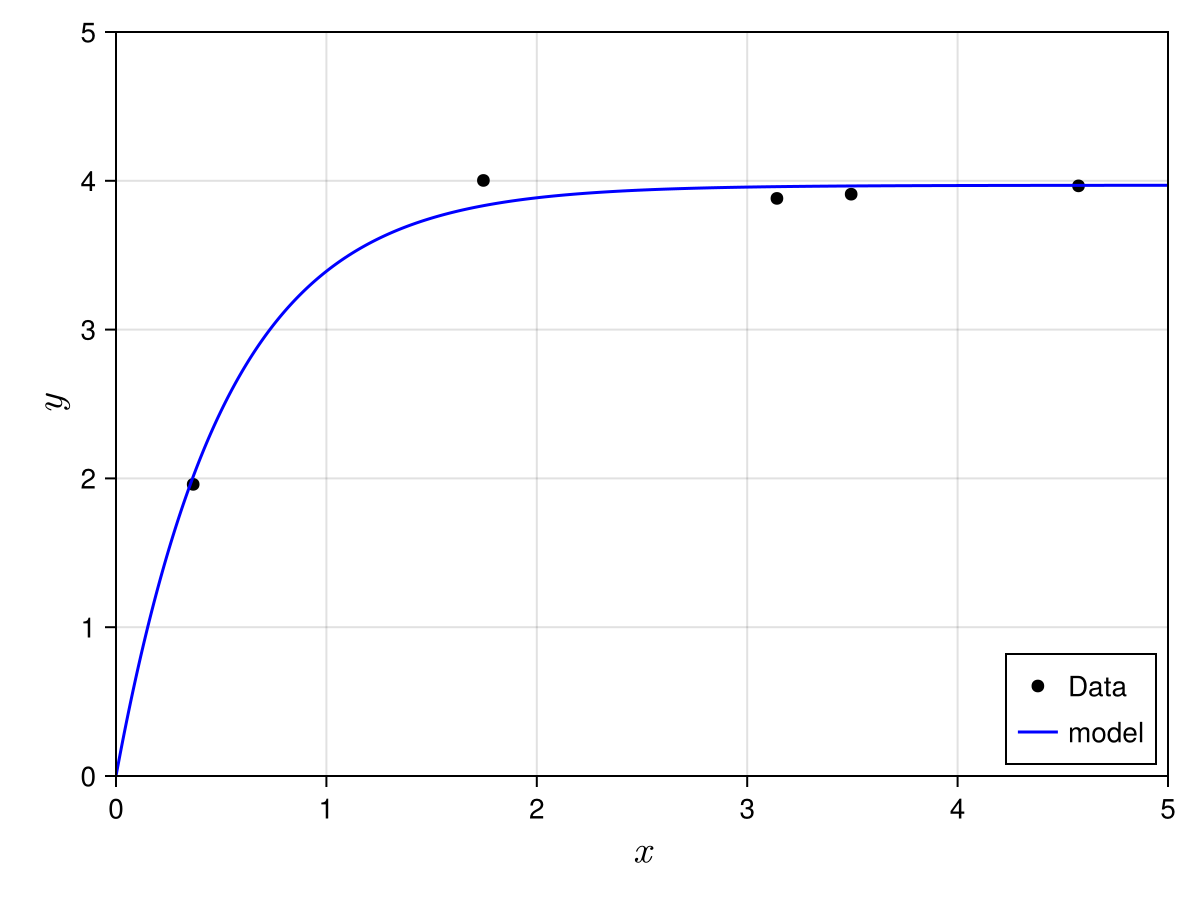

In [12]:
xplot=Array(0:0.01:5)


fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(0,5,0,5),
    xlabelsize = 20, # Set X label size
    ylabelsize = 20) 
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
lines!(ax,xplot,fmodel(a,xplot);label="model",color=:blue)
axislegend(ax;position = :rb)
fig

Prepared by Andrew Ooi 9th July 2026